<a href="https://colab.research.google.com/github/SiddharthJain2903/googlecamp/blob/main/Student_Grade.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
Predicted grade for studying 11.0 hours: 87.98/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


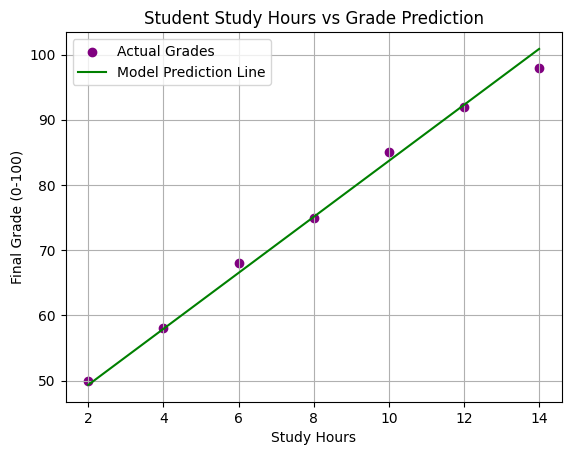

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# 1. Synthetic Data: Study Hours vs. Final Grade (out of 100)
study_hours = np.array([2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0], dtype=float)
student_grades = np.array([50.0, 58.0, 68.0, 75.0, 85.0, 92.0, 98.0], dtype=float)

# 2. Normalization Scaling Factors
# Max possible study hours could be ~24, max grade is 100
scaling_factor_hours = 24.0
scaling_factor_grade = 100.0

normalized_study_hours = study_hours / scaling_factor_hours
normalized_student_grades = student_grades / scaling_factor_grade

# 3. Build the Linear Regression Model
model = tf.keras.Sequential([
    tf.keras.Input(shape=(1,)),
    tf.keras.layers.Dense(units=1)
])

# 4. Compile the Model
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.05), loss='mean_squared_error')

# 5. Train the Model (Increased epochs slightly for better convergence on this toy data)
model.fit(normalized_study_hours, normalized_student_grades, epochs=1000, verbose=0)

# 6. Predict for a new student who studied for 11 hours
new_student_hours = np.array([11.0])
normalized_prediction_input = new_student_hours / scaling_factor_hours
normalized_predicted_grade = model.predict(normalized_prediction_input)

# Denormalize the prediction back to the original scale
predicted_grade = normalized_predicted_grade[0][0] * scaling_factor_grade

print(f"Predicted grade for studying {new_student_hours[0]} hours: {predicted_grade:.2f}/100")

# 7. Plotting the Actual Data vs. Model Predictions
plt.scatter(study_hours, student_grades, color='purple', label='Actual Grades')

predicted_plot_grades = model.predict(normalized_study_hours) * scaling_factor_grade
plt.plot(study_hours, predicted_plot_grades, color='green', label='Model Prediction Line')

plt.xlabel('Study Hours')
plt.ylabel('Final Grade (0-100)')
plt.legend()
plt.title('Student Study Hours vs Grade Prediction')
plt.grid(True)
plt.show()

# 8. Save and reload the model
model.save('student_grade_model.keras')
new_model = tf.keras.models.load_model('student_grade_model.keras')